# Prequisites

In [58]:
# Cloning the main repo
! git clone https://github.com/amirberenji1995/ml_for_pdm_project.git

fatal: destination path 'ml_for_pdm_project' already exists and is not an empty directory.


In [6]:
# Cloning Damavand
!git clone https://github.com/pydamavand/damavand

Cloning into 'damavand'...
remote: Enumerating objects: 357, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 357 (delta 33), reused 44 (delta 14), pack-reused 289 (from 1)
Receiving objects: 100% (357/357), 9.19 MiB | 10.83 MiB/s, done.
Resolving deltas: 100% (177/177), done.


In [8]:
# Installing Damavand's dependencies
! pip install -r damavand/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycatch22: filename=pycatch22-0.4.5-cp312-cp312-linux_x86_64.whl size=113892 sha256=3fb06dbb6302ad044077ca2f0a2159f70a80fede4b6ae7a3d588e131e681889a
  Stored in directory: /root/.cache/pip/wheels/89/44/33/6f846a24d9908b045e0e6b7d8a4e66adc4dec8fdf14184c90c
Successfully built pycatch22


# Imports

In [22]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer, LabelEncoder

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,5)

# Dataset Handler class

In [4]:
import os
import scipy.io as sio
import pandas as pd
import numpy as np

# splitter function from damavand.damavand.utils
def splitter(array, win_len, hop_len, return_df = True):
    N = array.shape[0]
    m = 0
    ids = []
    while m + win_len <= N:
        ids.append([m, m + win_len])
        m = m + hop_len

    if return_df:
        return pd.DataFrame([array[i[0]: i[1]] for i in ids])
    else:
        return np.array([array[i[0]: i[1]] for i in ids])

# HUST class from damavand.damavand.datasets.digestors
class HUST:
    def __init__(
        self,
        base_directory="hust/HUST bearing a practical dataset for ball bearing fault diagnosis/HUST bearing dataset/",
    ):
        self.base_directory = base_directory
        self.data = {"vib": []}

    def mine(self, mining_params, annotate=True):
        for file in os.listdir(self.base_directory):
            mat_contents = sio.loadmat(self.base_directory + file)
            temp_df = splitter(
                mat_contents["data"].reshape((-1)),
                win_len=mining_params["win_len"],
                hop_len=mining_params["hop_len"],
            )
            fs_value = mat_contents.get("fs", None)
            temp_df["fs"] = fs_value.item() if fs_value is not None else None
            temp_df["file"] = file

            if annotate:
                temp_df = self._annotate(temp_df)

            self.data["vib"].append(temp_df)

    def _annotate(self, df):
        """
        A private method to annotate the dataset
        """
        df[["fault", "bearing", "power"]] = df["file"].str.extract(
            r"([A-Za-z]+)(\d)(\d+)\.mat"
        )

        return df

# Downloading the dataset

In [9]:
link = "https://data.mendeley.com/public-api/zip/cbv7jyx4p9/download/3"
from damavand.damavand.datasets.downloaders import ZipDatasetDownloader

downloader = ZipDatasetDownloader(url = link)
downloader.download_extract('hust.zip', 'hust/')

# Mining the dataset

In [15]:
dataset = HUST()
dataset.mine({
    "win_len": 5000,
    "hop_len": 5000
})

In [16]:
df = pd.concat(dataset.data["vib"]).reset_index(drop=True)
df

,0,1,2,3,4,5,6,7,8,9,...,4995,4996,4997,4998,4999,fs,file,fault,bearing,power
0,-1.316556,0.435126,-0.186442,0.399682,1.160356,-1.568958,0.414807,0.404406,0.176945,0.137769,...,-0.405844,1.187863,0.243127,-0.448586,1.484269,24.06,B802.mat,B,8,02
1,-0.608073,-1.134439,0.800744,-0.074214,0.010319,0.730934,1.563302,1.143232,0.166861,-0.938020,...,0.920501,-1.166244,-0.243979,1.328488,0.020884,24.06,B802.mat,B,8,02
2,0.892762,1.053383,0.498077,-0.395242,-2.077444,0.390147,-0.448927,-0.477525,0.261629,0.330348,...,-1.326457,0.188113,-0.340076,-0.829773,0.401754,24.06,B802.mat,B,8,02
3,-0.799407,0.730806,-0.659331,-1.762963,-0.389658,-0.424505,-0.278454,-0.008007,0.468418,-0.008147,...,-0.697098,-0.274376,0.485476,-2.347489,-0.039842,24.06,B802.mat,B,8,02
4,0.442045,-0.339540,-0.838735,1.410179,-1.479866,-0.558034,3.081536,0.330482,-5.485217,0.566070,...,-0.842978,-1.821598,0.338480,1.061229,-0.388201,24.06,B802.mat,B,8,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9733,0.358860,0.257088,-0.185734,-0.663080,-0.048798,0.426963,-0.415379,-0.955816,-0.443532,0.769628,...,-0.516645,-0.081700,-0.583614,-0.232829,-0.331560,23.10,OB404.mat,OB,4,04
9734,-1.577853,-0.571464,0.154150,0.080988,-0.056516,0.536795,-0.234286,-0.114163,0.061077,0.266135,...,-0.179138,0.298634,-0.174261,0.571563,0.678097,23.10,OB404.mat,OB,4,04
9735,0.287039,-0.079450,-0.671066,0.035820,-0.055662,-0.322531,0.247205,0.499498,-0.536203,-1.184192,...,-0.088619,0.021975,-0.242839,-1.895681,-1.280777,23.10,OB404.mat,OB,4,04
9736,0.621468,0.737829,-0.219545,-0.890420,0.942472,-0.015999,-0.264042,1.932693,1.150919,0.415008,...,1.084146,1.546921,-0.037812,0.006929,0.460152,23.10,OB404.mat,OB,4,04


In [18]:
df["fault"].value_counts()

,count
fault,
IO,1530
I,1530
N,1530
O,1530
OB,1346
IB,1234
B,1038


In [19]:
signals, metadata = df.iloc[:, :-5], df.iloc[:, -5:]
signals

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,-1.316556,0.435126,-0.186442,0.399682,1.160356,-1.568958,0.414807,0.404406,0.176945,0.137769,...,0.564588,-0.952353,0.140781,1.242273,-0.500228,-0.405844,1.187863,0.243127,-0.448586,1.484269
1,-0.608073,-1.134439,0.800744,-0.074214,0.010319,0.730934,1.563302,1.143232,0.166861,-0.938020,...,0.511075,-0.661288,-2.382842,-1.190928,-0.768980,0.920501,-1.166244,-0.243979,1.328488,0.020884
2,0.892762,1.053383,0.498077,-0.395242,-2.077444,0.390147,-0.448927,-0.477525,0.261629,0.330348,...,-0.096313,-0.051846,0.651992,-0.844447,0.048823,-1.326457,0.188113,-0.340076,-0.829773,0.401754
3,-0.799407,0.730806,-0.659331,-1.762963,-0.389658,-0.424505,-0.278454,-0.008007,0.468418,-0.008147,...,0.263702,-0.638323,0.213419,0.242792,0.697130,-0.697098,-0.274376,0.485476,-2.347489,-0.039842
4,0.442045,-0.339540,-0.838735,1.410179,-1.479866,-0.558034,3.081536,0.330482,-5.485217,0.566070,...,-0.744138,1.753125,-1.283807,-0.272754,1.367761,-0.842978,-1.821598,0.338480,1.061229,-0.388201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9733,0.358860,0.257088,-0.185734,-0.663080,-0.048798,0.426963,-0.415379,-0.955816,-0.443532,0.769628,...,0.914356,0.133484,-0.720965,0.220150,0.529004,-0.516645,-0.081700,-0.583614,-0.232829,-0.331560
9734,-1.577853,-0.571464,0.154150,0.080988,-0.056516,0.536795,-0.234286,-0.114163,0.061077,0.266135,...,-0.491400,-0.161209,0.165416,-0.236505,-0.044451,-0.179138,0.298634,-0.174261,0.571563,0.678097
9735,0.287039,-0.079450,-0.671066,0.035820,-0.055662,-0.322531,0.247205,0.499498,-0.536203,-1.184192,...,0.877850,-0.285819,0.393677,-0.105451,-0.368821,-0.088619,0.021975,-0.242839,-1.895681,-1.280777
9736,0.621468,0.737829,-0.219545,-0.890420,0.942472,-0.015999,-0.264042,1.932693,1.150919,0.415008,...,-0.342948,-0.936972,-0.594636,0.795738,0.714901,1.084146,1.546921,-0.037812,0.006929,0.460152


# Encoding fault and power columns

In [59]:
fault_encoder = LabelEncoder()
metadata["fault_encoded"] = fault_encoder.fit_transform(metadata["fault"])
power_encoder = LabelEncoder()
metadata["power_encoded"] = power_encoder.fit_transform(metadata["power"])

# Extracting time domain features

In [20]:
from damavand.damavand.signal_processing.feature_extraction import feature_extractor, smsa, rms, peak, crest_factor, clearance_factor, shape_factor, impulse_factor
import scipy




time_features = {
  'mean': (np.mean, (), {}),
  'std': (np.std, (), {}),
  'smsa': (smsa, (), {}),
  'rms': (rms, (), {}),
  'peak': (peak, (), {}),
  'skew': (scipy.stats.skew, (), {}),
  'kurtosis': (scipy.stats.kurtosis, (), {}),
  'crest_factor': (crest_factor, (), {}),
  'clearance_factor': (clearance_factor, (), {}),
  'shape_factor': (shape_factor, (), {}),
  'impulse_factor': (impulse_factor, (), {}),
}
time_features_df = feature_extractor(signals, time_features)

# Feature, target and auxiliary declaration

In [60]:
x = time_features_df
y = metadata["fault_encoded"]
z = metadata["power_encoded"]

# Train/Test splitting

In [61]:
x_train, x_test, y_train, y_test, z_train, z_test = train_test_split(x, y, z, test_size=0.25, random_state=25)

print(x_train.shape, " --- ", x_test.shape)
print(y_train.shape, " --- ", y_test.shape)
print(z_train.shape, " --- ", z_test.shape)

(7303, 11)  ---  (2435, 11)
(7303,)  ---  (2435,)
(7303,)  ---  (2435,)


# Label Binarizing

In [62]:
binarizer = LabelBinarizer()

y_train_bin = binarizer.fit_transform(y = y_train)
y_test_bin = binarizer.transform(y = y_test)

# Feature Scaling

In [63]:
feature_scaler = MinMaxScaler()
x_train_scaled = feature_scaler.fit_transform(x_train)
x_test_scaled = feature_scaler.transform(x_test)

# Fitting a Random Forest on the auxiliary task

In [64]:
rF = RandomForestClassifier()
rF.fit(x_train_scaled, z_train)

RandomForestClassifier()

In [65]:
from tabulate import tabulate
print(tabulate([
    ['Training Accuracy: ', rF.score(x_train_scaled, z_train)],
    ['Testing Accuracy: ', rF.score(x_test_scaled, z_test)],
]))

------------------  --------
Training Accuracy:  1
Testing Accuracy:   0.800821
------------------  --------


# Forming the new feature-set

In [66]:
z_train_prob = rF.predict_proba(x_train_scaled)
z_test_prob = rF.predict_proba(x_test_scaled)

In [67]:
z_train_prob.shape

(7303, 3)

In [68]:
x_train_scaled = np.concatenate([x_train_scaled, z_train_prob], axis = 1)
x_train_scaled.shape

(7303, 14)

In [69]:
x_test_scaled = np.concatenate([x_test_scaled, z_test_prob], axis = 1)
x_test_scaled.shape

(2435, 14)

# Training an ANN on the main task

In [70]:
def model_creator():

  input = Input(shape=(14,), name='input')
  emb = Dense(units = 14, activation='relu', name = 'HL1',)(input)
  emb = Dense(units = 14, activation='relu', name = 'HL2',)(emb)
  predicted_values = Dense(units = 7, activation='softmax')(emb)

  return Model(inputs = input, outputs = predicted_values)

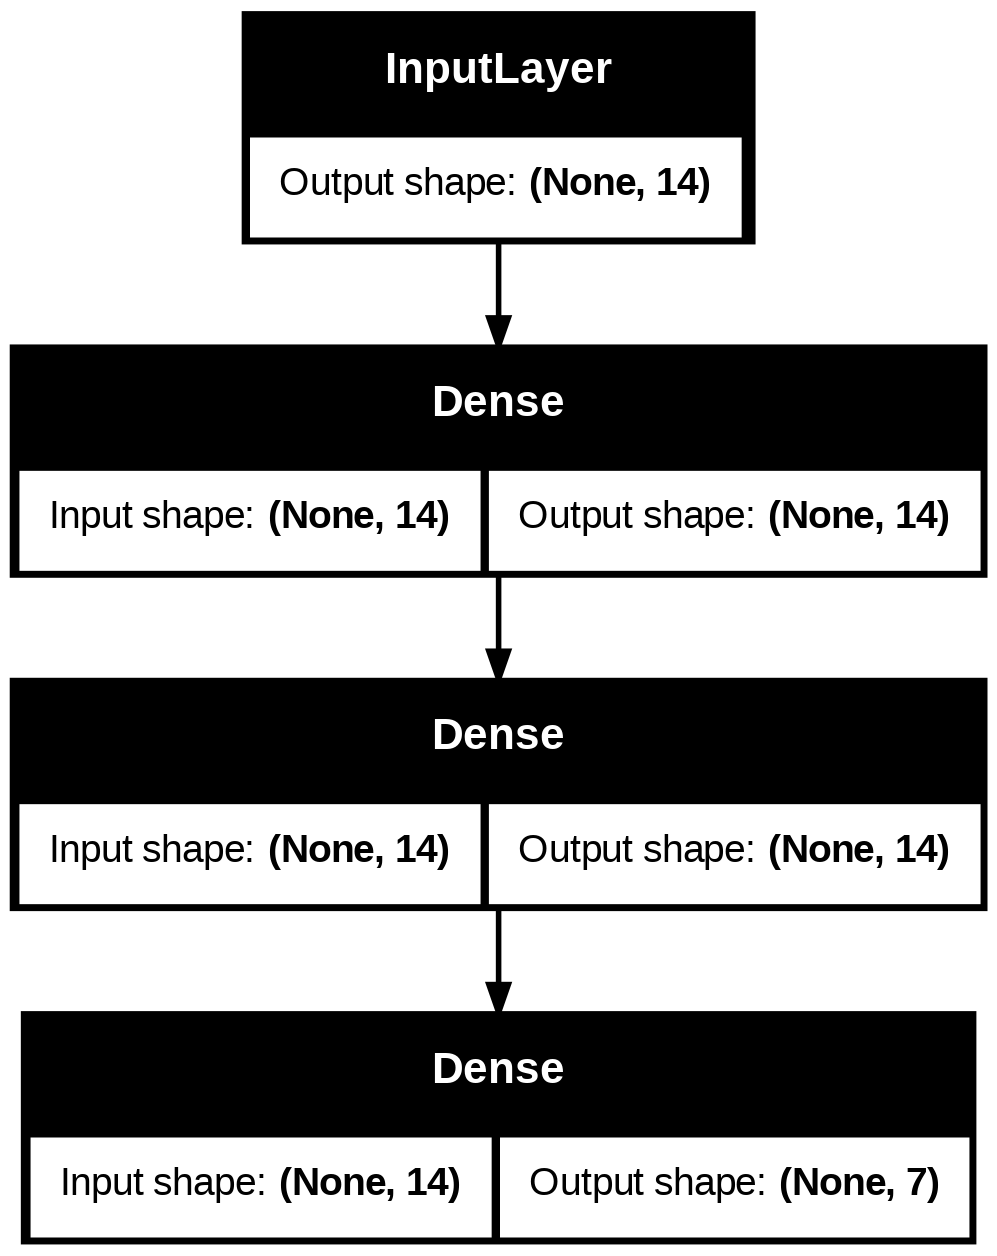

In [71]:
model = model_creator()
plot_model(model, show_shapes = True)

In [72]:
# best_model_saver = SaveBestModel('val_loss')

model = model_creator()

lr = 0.001
ep = 500
opt = optimizers.Adam(learning_rate=lr, weight_decay=lr / ep)

model.compile(loss = 'crossentropy', optimizer=opt, metrics=["accuracy"])

history  = model.fit(x = x_train_scaled, y = y_train_bin,
                     validation_split = 0.25, epochs = ep,
                    #  callbacks=[best_model_saver]
                     )

# model.set_weights(best_model_saver.best_weights)

Epoch 1/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2291 - loss: 1.9013 - val_accuracy: 0.2634 - val_loss: 1.7993
Epoch 2/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3058 - loss: 1.6906 - val_accuracy: 0.3395 - val_loss: 1.5403
Epoch 3/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4366 - loss: 1.4420 - val_accuracy: 0.4786 - val_loss: 1.3340
Epoch 4/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5313 - loss: 1.2685 - val_accuracy: 0.5597 - val_loss: 1.1790
Epoch 5/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5777 - loss: 1.1406 - val_accuracy: 0.5920 - val_loss: 1.0809
Epoch 6/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6027 - loss: 1.0580 - val_accuracy: 0.6418 - val_loss: 1.0164
Epoch 7/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6253 - loss: 0.9947 - val_accuracy: 0.6495 - val_loss: 0.9540
Epoch 8/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6403 - loss: 0.9410 - val_a

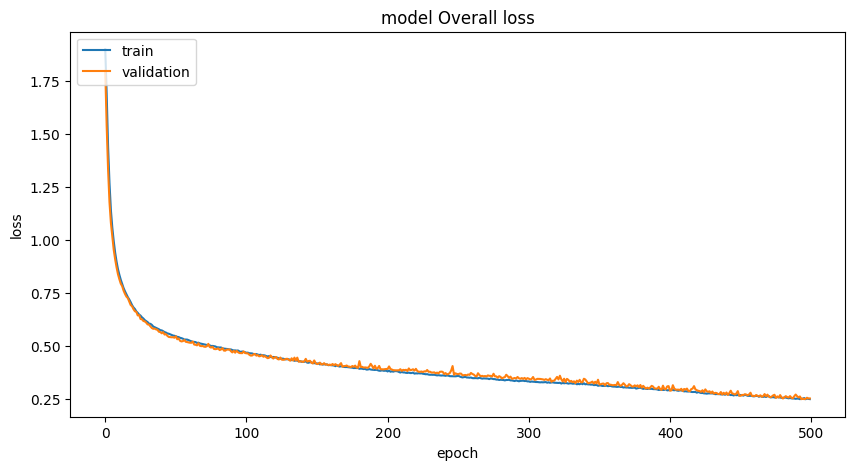

In [73]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model Overall loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [74]:
model.evaluate(x_test_scaled, y_test_bin)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9179 - loss: 0.2698


[0.2697718143463135, 0.9178645014762878]

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_test_pred = model.predict(x_test_scaled)

confusion_matrix(y_test, np.argmax(y_test_pred, axis=1))

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[241,   0,   5,   1,   0,   3,  24],
       [  0, 369,   0,   3,   0,  18,   0],
       [  4,   0, 290,   1,   0,   0,  12],
       [  0,  10,   1, 363,   0,  21,   3],
       [  0,   0,   0,   0, 382,   0,   0],
       [  4,   4,   0,  19,   0, 315,  26],
       [  8,   1,   5,  13,   0,  14, 275]])

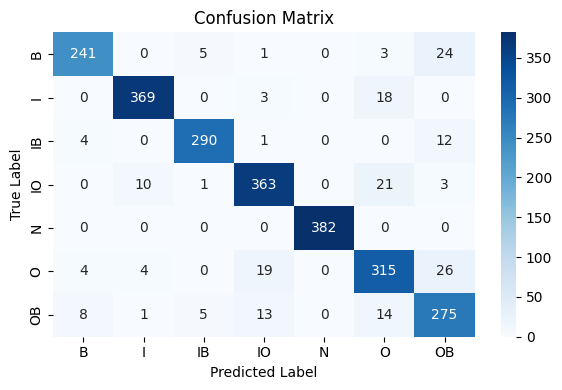

In [79]:
# unique_labels = sorted(y_labels.unique())
cm = confusion_matrix(y_test, np.argmax(y_test_pred, axis=1), labels=np.arange(len(fault_encoder.classes_)))

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=fault_encoder.classes_,
    yticklabels=fault_encoder.classes_,
)
plt.title(f"Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()